nie opisywać teorii

co najwyżej metoda dopasowania sie do dystrybuanty -  Miałem to zapisane w tym pliku więc pewnie tak na zajęciach mówił

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress#, levy_stable
import seaborn as sns
from tqdm import tqdm # Do paska postępu w symulacjach

In [34]:
# # The alpha stable distribution 
# def genZ(alpha, beta, theta, W):
#   if alpha == 1: 
#     Z = (2/np.pi) * (((np.pi/2)+beta*theta)*np.tan(theta) - beta*np.log((np.pi/2)*W*np.cos(theta)/((np.pi/2)+beta*theta)))
#   else:
#     theta0 = np.arctan(beta*np.tan(np.pi*alpha/2))/alpha
#     Z = (np.sin(alpha*(theta0 + theta))/((np.cos(alpha*theta0)*np.cos(theta))**(1/alpha))) * ((np.cos(alpha*theta0 + (alpha - 1)*theta)/W)**((1-alpha)/alpha))
#   return Z
def genZ(alpha, beta, N):
    theta = np.random.uniform(-np.pi/2, np.pi/2, N)
    W = np.random.exponential(1, N)
    if alpha == 1: 
        Z = (2/np.pi) * (((np.pi/2)+beta*theta)*np.tan(theta) - beta*np.log((np.pi/2)*W*np.cos(theta)/((np.pi/2)+beta*theta)))
    else:
        theta0 = np.arctan(beta*np.tan(np.pi*alpha/2))/alpha
        Z = (np.sin(alpha*(theta0 + theta))/((np.cos(alpha*theta0)*np.cos(theta))**(1/alpha))) * ((np.cos(alpha*theta0 + (alpha - 1)*theta)/W)**((1-alpha)/alpha))
    return Z

In [35]:
def S(alpha, beta, gamma, delta, zeroOne, Z):
    if zeroOne == 0:
        if alpha == 1:
            X = gamma*Z + delta
        else:
            X = gamma*(Z - beta*np.tan(np.pi/2*(alpha))) + delta
    else:
        if alpha == 1:
            X = gamma*Z + (delta + beta*(2/np.pi)*gamma*np.log(gamma))
        else:
            X = gamma*Z + delta
    return X

In [36]:
def generate_sample(N, alpha, beta, gamma, delta):
    Z = genZ(alpha, beta, N)
    X = S(alpha, beta, gamma, delta, 0, Z)  # Używamy zeroOne=0
    return X

In [37]:
def estimate_alpha_ecdf(t, tail_fraction=0.1):
    t = np.sort(t)
    t_pos = t[t > 0] # Zabezpieczenie przed logarytmowaniem wartości ujemnych
    if len(t_pos) < 2: return np.nan
    
    n_tail = int(len(t_pos) * tail_fraction)
    if n_tail < 2: return np.nan
    
    top_t = t_pos[-n_tail:]
    surv_probs = np.arange(n_tail, 0, -1) / len(t)
    
    lnt = np.log(top_t)
    lnfdce = np.log(surv_probs)
    
    # Współczynnik nachylenia c_1 = -alpha
    slope, intercept, r_val, p_val, std_err = linregress(lnt, lnfdce)
    
    return np.clip(slope, 0.1, 2.0)

In [38]:

def estimate_alpha_cf(X, t_max=1.0, num_t=50):
    t_vals = np.linspace(0.01, t_max, num_t)
    phi_n_abs = []
    
    for t in t_vals:
        phi = np.mean(np.exp(1j * t * X))
        phi_n_abs.append(np.abs(phi))
        
    phi_n_abs = np.array(phi_n_abs)
    
    valid_mask = (phi_n_abs > 0) & (phi_n_abs < 1)
    if not np.any(valid_mask): return np.nan
        
    t_valid = t_vals[valid_mask]
    phi_valid = phi_n_abs[valid_mask]
    
    y = np.log(-np.log(phi_valid))
    x = np.log(t_valid)
    
    slope, intercept, r_val, p_val, std_err = linregress(x, y)
    return np.clip(slope, 0.1, 2.0)

In [39]:
# # Funkcja do estymacji alpha metodą ECDF (regresja w ogonie)
# def estimate_alpha_ecdf(X, tail_fraction=0.1):
#     """
#     Estymuje parametr alpha na podstawie prawego ogona ECDF.
#     Wykorzystuje zależność: log(1 - F(x)) ~ -alpha * log(x) dla dużych x.
#     """
#     X_sorted = np.sort(X)
#     X_pos = X_sorted[X_sorted > 0]
    
#     if len(X_pos) == 0:
#         return np.nan
        
#     n_tail = int(len(X_pos) * tail_fraction)
#     if n_tail < 2:
#         return np.nan
        
#     # Wybieramy tylko największe wartości (ogon)
#     X_tail = X_pos[-n_tail:]
    
#     # Empiryczne prawdopodobieństwa przetrwania P(X > x)
#     # Odpowiada to 1 - F(x)
#     surv_probs = np.arange(n_tail, 0, -1) / len(X_sorted)
    
#     # Regresja liniowa: y = log(1-F(x)), x = log(x)
#     log_x = np.log(X_tail)
#     log_y = np.log(surv_probs)
    
#     slope, intercept, r_val, p_val, std_err = linregress(log_x, log_y)
    
#     # Zgodnie ze wzorem, współczynnik kierunkowy to -alpha
#     alpha_est = -slope
#     return np.clip(alpha_est, 0.1, 2.0) # alpha zawiera się w (0, 2]

In [40]:
# # Funkcja do estymacji alpha metodą CF (funkcja charakterystyczna)
# def estimate_alpha_cf(X, t_max=1.0, num_t=50):
#     """
#     Estymuje parametr alpha używając empirycznej funkcji charakterystycznej (ECF).
#     Wykorzystuje zależność: log(-log|phi(t)|) = alpha * log(t) + alpha * log(gamma)
#     """
#     # Wybieramy siatkę punktów t blisko zera (pomijamy t=0)
#     t_vals = np.linspace(0.01, t_max, num_t)
    
#     # Obliczanie modułu empirycznej funkcji charakterystycznej
#     phi_n_abs = np.array([np.abs(np.mean(np.exp(1j * t * X))) for t in t_vals])
    
#     # Zabezpieczenie przed logarytmowaniem zera lub jedynki
#     valid_mask = (phi_n_abs > 0) & (phi_n_abs < 1)
#     if not np.any(valid_mask):
#         return np.nan
        
#     t_valid = t_vals[valid_mask]
#     phi_valid = phi_n_abs[valid_mask]
    
#     y = np.log(-np.log(phi_valid))
#     x = np.log(t_valid)
    
#     slope, intercept, r_val, p_val, std_err = linregress(x, y)
    
#     alpha_est = slope
#     return np.clip(alpha_est, 0.1, 2.0)

In [41]:
# Ustawienie parametrów rozkładu (punkt i oraz ii)
true_alpha = 1.5
beta = 0.0     # Symetryczny rozkład (ułatwia CF)
gamma = 1.0    # Skala
delta = 0.0    # Położenie
n_samples = 1000

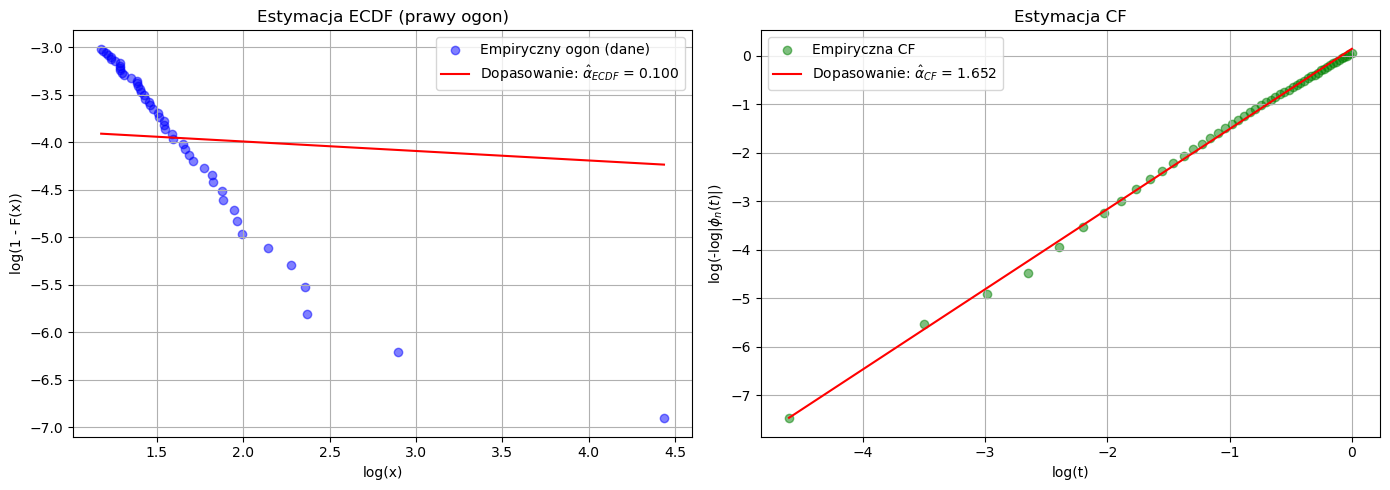

In [42]:
np.random.seed(42)
# X_sample = levy_stable.rvs(true_alpha, beta, loc=delta, scale=gamma, size=n_samples)
X_sample = generate_sample(n_samples, true_alpha, beta, gamma, delta)

# Obliczenia dla wykresów
alpha_ecdf = estimate_alpha_ecdf(X_sample)
alpha_cf = estimate_alpha_cf(X_sample)

plt.figure(figsize=(14, 5))

# Wykres 1: Dopasowanie w ogonie ECDF (skala log-log)
plt.subplot(1, 2, 1)
X_sorted = np.sort(X_sample)
X_pos = X_sorted[X_sorted > 0]
tail_frac = 0.1
n_tail = int(len(X_pos) * tail_frac)
X_tail = X_pos[-n_tail:]
surv_probs = np.arange(n_tail, 0, -1) / len(X_sorted)

log_x = np.log(X_tail)
log_y = np.log(surv_probs)

plt.scatter(log_x, log_y, color='blue', alpha=0.5, label='Empiryczny ogon (dane)')
# Generowanie linii dopasowania
fit_y = -alpha_ecdf * log_x + (log_y.mean() - (-alpha_ecdf * log_x.mean()))
plt.plot(log_x, fit_y, color='red', label=f'Dopasowanie: $\\hat{{\\alpha}}_{{ECDF}}$ = {alpha_ecdf:.3f}')
plt.xlabel('log(x)')
plt.ylabel('log(1 - F(x))')
plt.title('Estymacja ECDF (prawy ogon)')
plt.legend()
plt.grid(True)

# Wykres 2: Dopasowanie dla CF
plt.subplot(1, 2, 2)
t_vals = np.linspace(0.01, 1.0, 50)
phi_n_abs = np.array([np.abs(np.mean(np.exp(1j * t * X_sample))) for t in t_vals])
valid = (phi_n_abs > 0) & (phi_n_abs < 1)
log_t = np.log(t_vals[valid])
log_neg_log_phi = np.log(-np.log(phi_n_abs[valid]))

plt.scatter(log_t, log_neg_log_phi, color='green', alpha=0.5, label='Empiryczna CF')
fit_y_cf = alpha_cf * log_t + (log_neg_log_phi.mean() - alpha_cf * log_t.mean())
plt.plot(log_t, fit_y_cf, color='red', label=f'Dopasowanie: $\\hat{{\\alpha}}_{{CF}}$ = {alpha_cf:.3f}')
plt.xlabel('log(t)')
plt.ylabel('log(-log|$\phi_n(t)$|)')
plt.title('Estymacja CF')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Symulacja Monte Carlo: 100%|██████████| 1000/1000 [00:01<00:00, 608.32it/s]


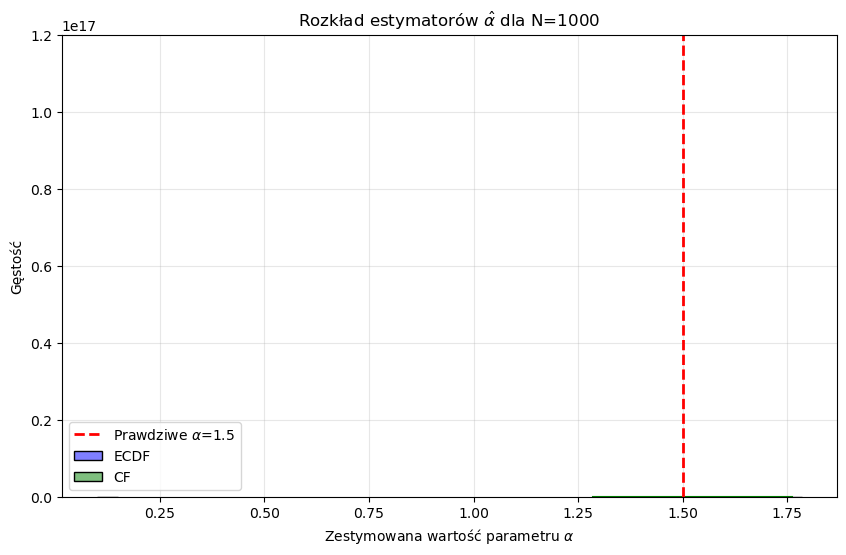

In [43]:
M = 1000 # Liczba powtórzeń Monte Carlo
alpha_ecdf_results = []
alpha_cf_results = []

for _ in tqdm(range(M), desc="Symulacja Monte Carlo"):
    # X_mc = levy_stable.rvs(true_alpha, beta, loc=delta, scale=gamma, size=n_samples)
    X_mc = generate_sample(n_samples, true_alpha, beta, gamma, delta)

    alpha_ecdf_results.append(estimate_alpha_ecdf(X_mc))
    alpha_cf_results.append(estimate_alpha_cf(X_mc))

# Oczyszczenie wyników z ewentualnych wartości NaN
res_ecdf = np.array(alpha_ecdf_results)[~np.isnan(alpha_ecdf_results)]
res_cf = np.array(alpha_cf_results)[~np.isnan(alpha_cf_results)]

# Wizualizacja rozkładów (Histogramy)
plt.figure(figsize=(10, 6))
sns.histplot(res_ecdf, color='blue', alpha=0.5, label='ECDF', kde=True, stat="density", binwidth=0.05)
sns.histplot(res_cf, color='green', alpha=0.5, label='CF', kde=True, stat="density", binwidth=0.05)
plt.axvline(true_alpha, color='red', linestyle='--', linewidth=2, label=f'Prawdziwe $\\alpha$={true_alpha}')
plt.title(f'Rozkład estymatorów $\\hat{{\\alpha}}$ dla N={n_samples}')
plt.xlabel('Zestymowana wartość parametru $\\alpha$')
plt.ylabel('Gęstość')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Przeszukiwanie siatki alpha: 100%|██████████| 4/4 [00:04<00:00,  1.15s/it]


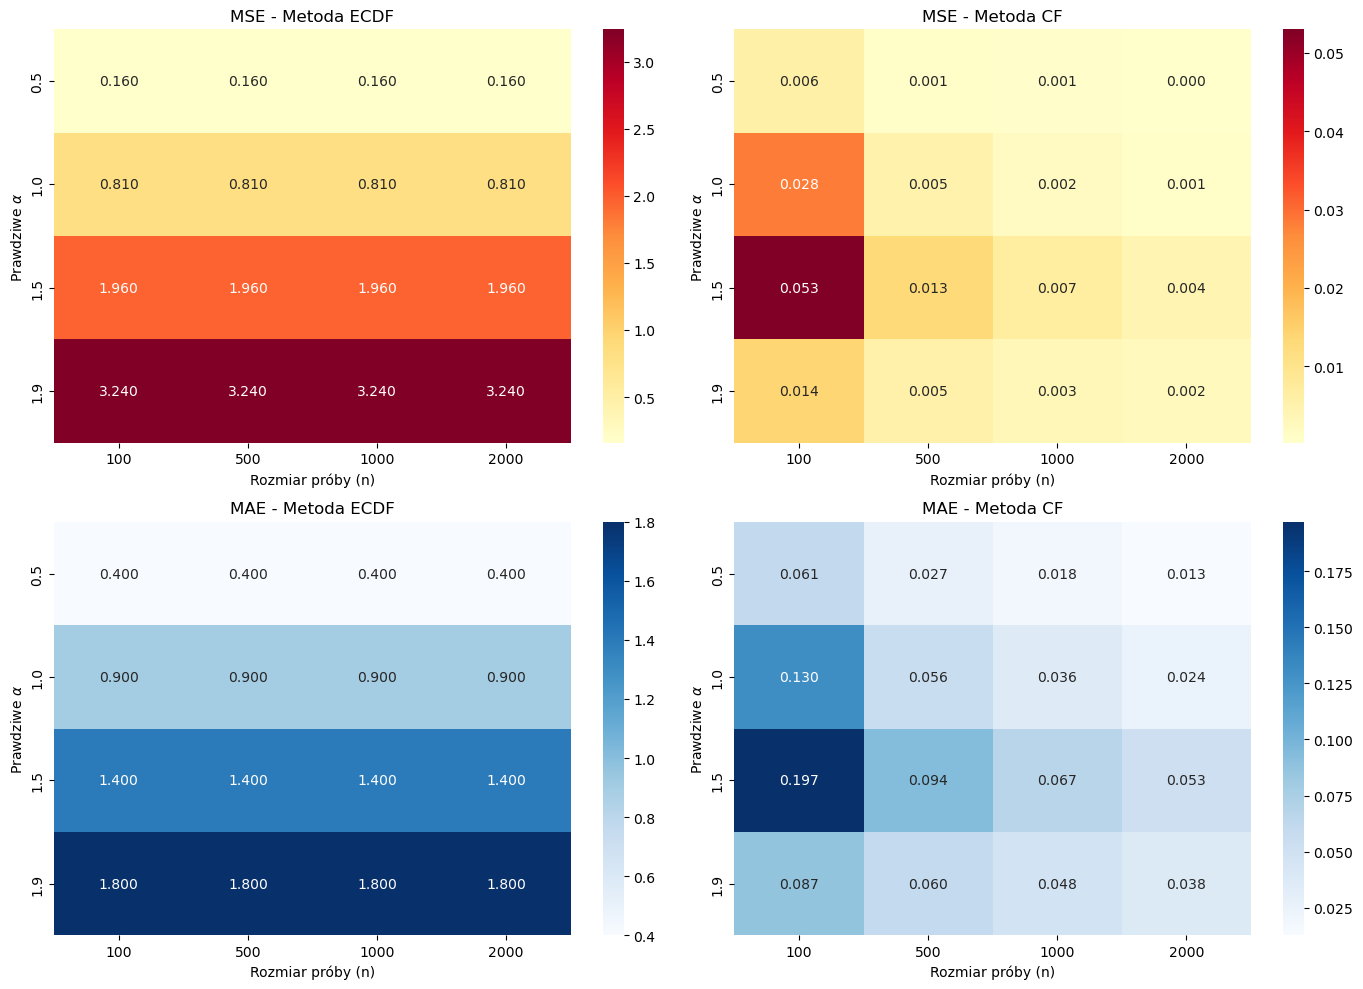

In [45]:
# Siatka parametrów
alpha_grid = [0.5, 1.0, 1.5, 1.9]
n_grid = [100, 500, 1000, 2000]
M_heat = 200 # Mniejsza liczba powtórzeń dla oszczędności czasu na siatce

# Inicjalizacja macierzy na błędy
mse_ecdf_matrix = np.zeros((len(alpha_grid), len(n_grid)))
mae_ecdf_matrix = np.zeros((len(alpha_grid), len(n_grid)))
mse_cf_matrix = np.zeros((len(alpha_grid), len(n_grid)))
mae_cf_matrix = np.zeros((len(alpha_grid), len(n_grid)))

for i, a in enumerate(tqdm(alpha_grid, desc="Przeszukiwanie siatki alpha")):
    for j, n in enumerate(n_grid):
        
        est_ecdf = []
        est_cf = []
        
        for _ in range(M_heat):
            # X_sim = levy_stable.rvs(a, beta, loc=delta, scale=gamma, size=n)
            X_sim = generate_sample(n, a, beta, gamma, delta)
            est_ecdf.append(estimate_alpha_ecdf(X_sim))
            est_cf.append(estimate_alpha_cf(X_sim))
            
        est_ecdf = np.array(est_ecdf)[~np.isnan(est_ecdf)]
        est_cf = np.array(est_cf)[~np.isnan(est_cf)]
        
        # Błędy dla ECDF
        mse_ecdf_matrix[i, j] = np.mean((est_ecdf - a)**2)
        mae_ecdf_matrix[i, j] = np.mean(np.abs(est_ecdf - a))
        
        # Błędy dla CF
        mse_cf_matrix[i, j] = np.mean((est_cf - a)**2)
        mae_cf_matrix[i, j] = np.mean(np.abs(est_cf - a))

# Rysowanie heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(mse_ecdf_matrix, annot=True, fmt=".3f", xticklabels=n_grid, yticklabels=alpha_grid, ax=axes[0,0], cmap='YlOrRd')
axes[0,0].set_title('MSE - Metoda ECDF')
axes[0,0].set_xlabel('Rozmiar próby (n)')
axes[0,0].set_ylabel('Prawdziwe $\\alpha$')

sns.heatmap(mse_cf_matrix, annot=True, fmt=".3f", xticklabels=n_grid, yticklabels=alpha_grid, ax=axes[0,1], cmap='YlOrRd')
axes[0,1].set_title('MSE - Metoda CF')
axes[0,1].set_xlabel('Rozmiar próby (n)')
axes[0,1].set_ylabel('Prawdziwe $\\alpha$')

sns.heatmap(mae_ecdf_matrix, annot=True, fmt=".3f", xticklabels=n_grid, yticklabels=alpha_grid, ax=axes[1,0], cmap='Blues')
axes[1,0].set_title('MAE - Metoda ECDF')
axes[1,0].set_xlabel('Rozmiar próby (n)')
axes[1,0].set_ylabel('Prawdziwe $\\alpha$')

sns.heatmap(mae_cf_matrix, annot=True, fmt=".3f", xticklabels=n_grid, yticklabels=alpha_grid, ax=axes[1,1], cmap='Blues')
axes[1,1].set_title('MAE - Metoda CF')
axes[1,1].set_xlabel('Rozmiar próby (n)')
axes[1,1].set_ylabel('Prawdziwe $\\alpha$')

plt.tight_layout()
plt.show()